# DreamLens feature accentuation with torchvision ResNet18

This notebook demonstrates DreamLens's native PyTorch feature-accentuation API with a standard torchvision model. It imports no Faccent package, converted model, TensorFlow code, or helper runner. The iguana and fox images are checked into `learning_inputs/`, so the notebook has no runtime dependency on a reference repository.

The two tasks intentionally accentuate a new semantic target while preserving an earlier ResNet representation: **iguana → loggerhead** and **fox → castle**.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import torch
from torchvision.models import ResNet18_Weights, resnet18

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src' / 'dreamlens').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from dreamlens import FeatureAccentuationConfig, FeatureTarget, FeatureVisualizer

INPUTS_DIR = PROJECT_ROOT / 'learning_inputs'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'dreamlens_feature_accentuation_notebook'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('project:', PROJECT_ROOT)
print('device:', device)

project: /Users/susmered/Documents/arena/activation-atlas-pytorch
device: cpu


## Torchvision model and DreamLens configuration

`ResNet18_Weights.DEFAULT` supplies both the pretrained PyTorch weights and the standard ImageNet class vocabulary. `FeatureVisualizer(..., normalize=True)` applies the matching differentiable ImageNet normalization after DreamLens creates each paired crop. The default full-complex Fourier parameterization is the primary Faccent algorithm.

In [2]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights).to(device).eval()
categories = weights.meta['categories']
visualizer = FeatureVisualizer(
    model,
    device=device,
    normalize=True,
    quiet=True,
)

checkpoint_steps = (0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 98)
config = FeatureAccentuationConfig(
    width=512,
    height=512,
    input_shape=(3, 224, 224),
    steps=99,
    lr=0.05,
    crops=16,
    crop_min=0.05,
    crop_max=0.99,
    noise_std=0.02,
    regularization_strength=1.0,
    parameterization='fourier',
    resize_mode='nearest',
    checkpoint_steps=checkpoint_steps,
)
print('loggerhead class:', categories.index('loggerhead'))
print('castle class:', categories.index('castle'))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /tmp/xdg-cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  0%|          | 128k/44.7M [00:00<01:10, 660kB/s]

  1%|          | 384k/44.7M [00:00<00:36, 1.28MB/s]

  2%|▏         | 896k/44.7M [00:00<00:18, 2.52MB/s]

...

 79%|███████▉  | 35.4M/44.7M [00:01<00:00, 35.6MB/s]

 87%|████████▋ | 38.9M/44.7M [00:01<00:00, 35.3MB/s]

 95%|█████████▌| 42.5M/44.7M [00:01<00:00, 36.1MB/s]

100%|██████████| 44.7M/44.7M [00:01<00:00, 25.5MB/s]

loggerhead class: 33
castle class: 483


## Iguana → loggerhead

The target is torchvision's ImageNet loggerhead logit. `layer2.1` is an explicit preservation layer: DreamLens measures a one-time target/regularizer gradient ratio, then gives the candidate and fixed source exactly the same random crop and noise on every step.

In [3]:
torch.manual_seed(31415)
started = time.perf_counter()
iguana_result = visualizer.accentuate(
    target=FeatureTarget.for_class(categories.index('loggerhead'), layer='fc'),
    image=INPUTS_DIR / 'iguana.jpg',
    regularization_layer='layer2.1',
    config=config,
)
print(f'elapsed: {time.perf_counter() - started:.1f}s')
print('gradient balance:', iguana_result.metadata['gradient_balance'])
print('final target loss:', iguana_result.metadata['target_losses'][-1])
print('final preservation distance:', iguana_result.metadata['regularization_distances'][-1])

elapsed: 163.1s
gradient balance: 9.757087357786299
final target loss: -50.7388916015625
final preservation distance: 2.681906223297119


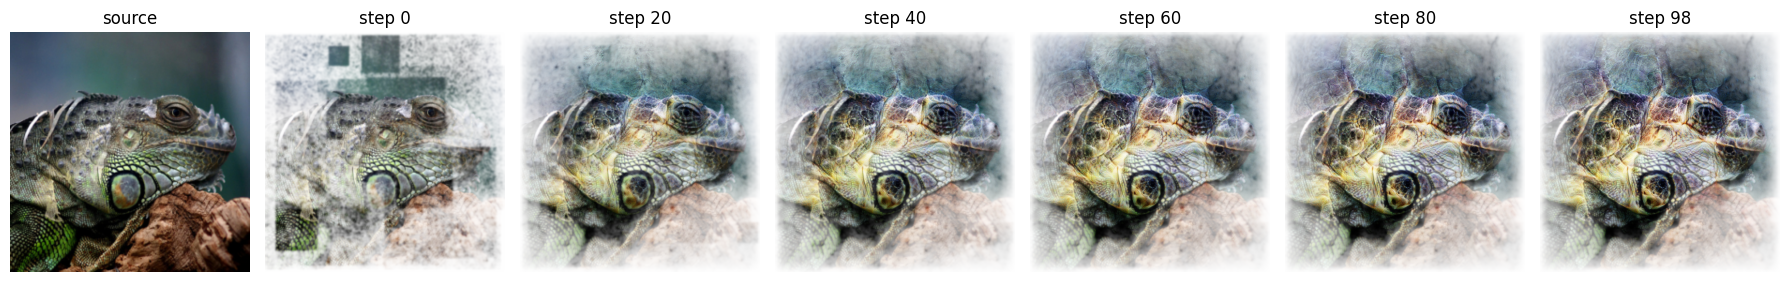

In [4]:
def white_composite(rgba):
    alpha = rgba[3:4]
    return (rgba[:3] * alpha + (1.0 - alpha)).permute(1, 2, 0).numpy()

trajectory_steps = (0, 20, 40, 60, 80, 98)
fig, axes = plt.subplots(1, len(trajectory_steps) + 1, figsize=(18, 3))
source = iguana_result.image.reference_image[0].detach().cpu().permute(1, 2, 0)
axes[0].imshow(source)
axes[0].set_title('source')
for axis, step in zip(axes[1:], trajectory_steps):
    axis.imshow(white_composite(iguana_result.as_accentuation_rgba(checkpoint=step)))
    axis.set_title(f'step {step}')
for axis in axes:
    axis.axis('off')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'resnet18_iguana_loggerhead_trajectory.png', dpi=160, bbox_inches='tight')
plt.show()
iguana_result.save_accentuation(
    RESULTS_DIR / 'resnet18_iguana_loggerhead_accentuation.png',
    checkpoint=98,
)

## Fox → castle

A second torchvision class target demonstrates that the same API is not tied to one image, model class, or Inception layer naming. The source remains a fox while ResNet's castle evidence is accentuated.

In [5]:
torch.manual_seed(27182)
started = time.perf_counter()
fox_result = visualizer.accentuate(
    target=FeatureTarget.for_class(categories.index('castle'), layer='fc'),
    image=INPUTS_DIR / 'fox.jpg',
    regularization_layer='layer2.1',
    config=config,
)
print(f'elapsed: {time.perf_counter() - started:.1f}s')
print('gradient balance:', fox_result.metadata['gradient_balance'])
print('final target loss:', fox_result.metadata['target_losses'][-1])
print('final preservation distance:', fox_result.metadata['regularization_distances'][-1])
fox_result.save_accentuation(
    RESULTS_DIR / 'resnet18_fox_castle_accentuation.png',
    checkpoint=98,
)

elapsed: 164.0s
gradient balance: 6.887587433168362
final target loss: -29.107004165649414
final preservation distance: 2.6524040699005127


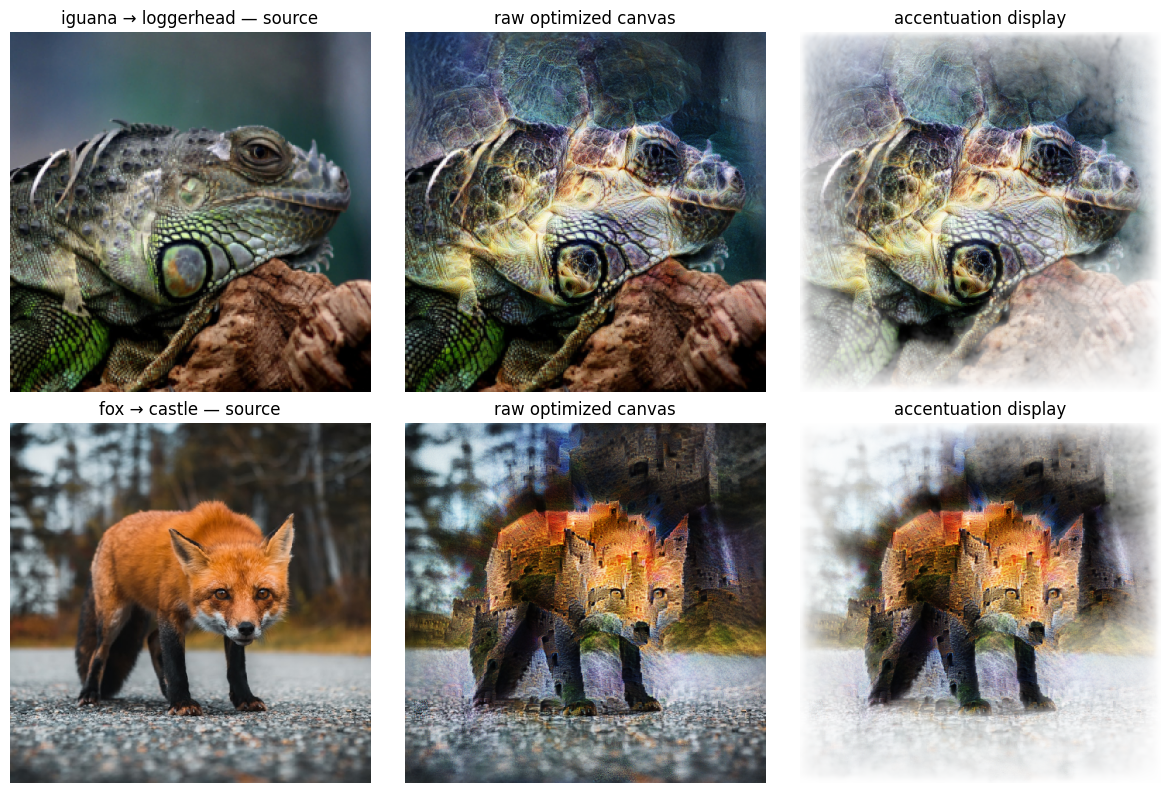

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
examples = [
    ('iguana → loggerhead', iguana_result),
    ('fox → castle', fox_result),
]
for row, (title, result) in enumerate(examples):
    source = result.image.reference_image[0].detach().cpu().permute(1, 2, 0)
    raw = result.checkpoints[98][0].permute(1, 2, 0)
    masked = white_composite(result.as_accentuation_rgba(checkpoint=98))
    axes[row, 0].imshow(source)
    axes[row, 0].set_title(f'{title} — source')
    axes[row, 1].imshow(raw)
    axes[row, 1].set_title('raw optimized canvas')
    axes[row, 2].imshow(masked)
    axes[row, 2].set_title('accentuation display')
for axis in axes.flat:
    axis.axis('off')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'torchvision_resnet18_feature_accentuation_examples.png', dpi=180, bbox_inches='tight')
plt.show()

## One shared MaCo magnitude asset

The runs above use Faccent's primary seeded full-complex Fourier parameterization, so their initial spectrum comes from each source image. If `parameterization='fourier_phase'` and `magnitude_source='imagenet'` are selected, DreamLens loads the same packaged `clean_decorrelated.npy` used by MaCo. That single asset comes from DreamLens's MaCo spectrum URL (`https://storage.googleapis.com/serrelab/loupe/spectrums/imagenet_decorrelated.npy`); no Faccent file or second NPY is used.

In [7]:
shared_magnitude_config = FeatureAccentuationConfig(
    parameterization='fourier_phase',
    magnitude_source='imagenet',
    regularization_strength=1.0,
)
shared_npy = PROJECT_ROOT / 'src/dreamlens/data/clean_decorrelated.npy'
print('optional phase-mode / MaCo magnitude:', shared_npy)
print('exists:', shared_npy.exists())

optional phase-mode / MaCo magnitude: /Users/susmered/Documents/arena/activation-atlas-pytorch/src/dreamlens/data/clean_decorrelated.npy
exists: True


## Public API summary

- `FeatureVisualizer.accentuate(...)` accepts any compatible PyTorch model and an explicit `FeatureTarget`.
- `FeatureAccentuationConfig` controls the 512-pixel canvas, 224-pixel model input, paired crops, regularization, Fourier mode, and checkpoints.
- `result.save()` writes the raw optimized canvas.
- `result.save_accentuation()` writes the contrast-normalized, attribution-masked presentation.
- Existing MaCo and caricature APIs are unchanged.